<a href="https://colab.research.google.com/github/GinoAlfaro/Ingenieria-del-conocimiento/blob/main/Sesion_02_ejercicio_3_con_TITANIC_ALFARO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 3 — Modelos de Clasificación con Titanic
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** Titanic de Kaggle (891 registros, 6 features utilizadas, clasificación binaria)

---

## 1. Configuración del entorno

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Titanic** contiene información de 891 pasajeros. La variable objetivo es **Survived**, donde **0 = no sobrevivió** y **1 = sobrevivió**. Para este ejercicio se trabajará con 6 features: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch` y `Fare`.

In [ ]:
df = pd.read_csv('titanic.csv')

print(f'Dataset original: {df.shape[0]} registros, {df.shape[1]} columnas')
print('\nColumnas disponibles:')
print(df.columns.tolist())

print('\nDistribución de clases:')
print(df['Survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'}).value_counts())

print(f'\nProporción: {df["Survived"].mean():.1%} sobrevivió, {1-df["Survived"].mean():.1%} no sobrevivió')

print('\nValores faltantes en las variables que utilizaremos:')
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
print(df[features].isnull().sum())

Dataset original: 891 registros, 12 columnas

Columnas disponibles:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Distribución de clases:
Survived
No sobrevivió    549
Sobrevivió       342
Name: count, dtype: int64

Proporción: 38.4% sobrevivió, 61.6% no sobrevivió

Valores faltantes en las variables que utilizaremos:
Pclass      0
Sex         0
Age       177
SibSp       0
Parch       0
Fare        0
dtype: int64


In [ ]:
df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].describe().round(3)

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000,891.000,714.000,891.000,891.000,891.000
mean,0.384,2.309,29.699,0.523,0.382,32.204
std,0.487,0.836,14.526,1.103,0.806,49.693
min,0.000,1.000,0.420,0.000,0.000,0.000
25%,0.000,2.000,20.125,0.000,0.000,7.910
50%,0.000,3.000,28.000,0.000,0.000,14.454
75%,1.000,3.000,38.000,1.000,0.000,31.000
max,1.000,3.000,80.000,8.000,6.000,512.329


---
## 3. Análisis exploratorio orientado a clasificación

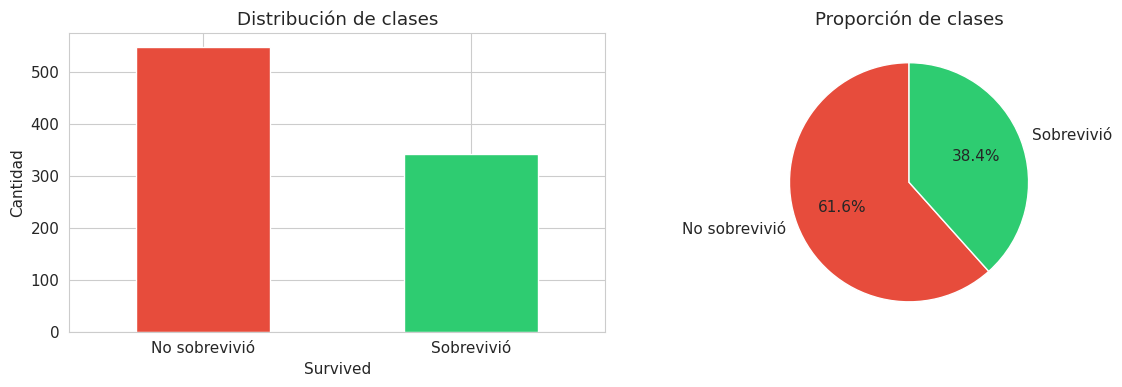

In [ ]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

survival_labels = df['Survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})
colors = ['#e74c3c', '#2ecc71']

survival_labels.value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['No sobrevivió', 'Sobrevivió'], rotation=0)

survival_labels.value_counts().plot(
    kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90
)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

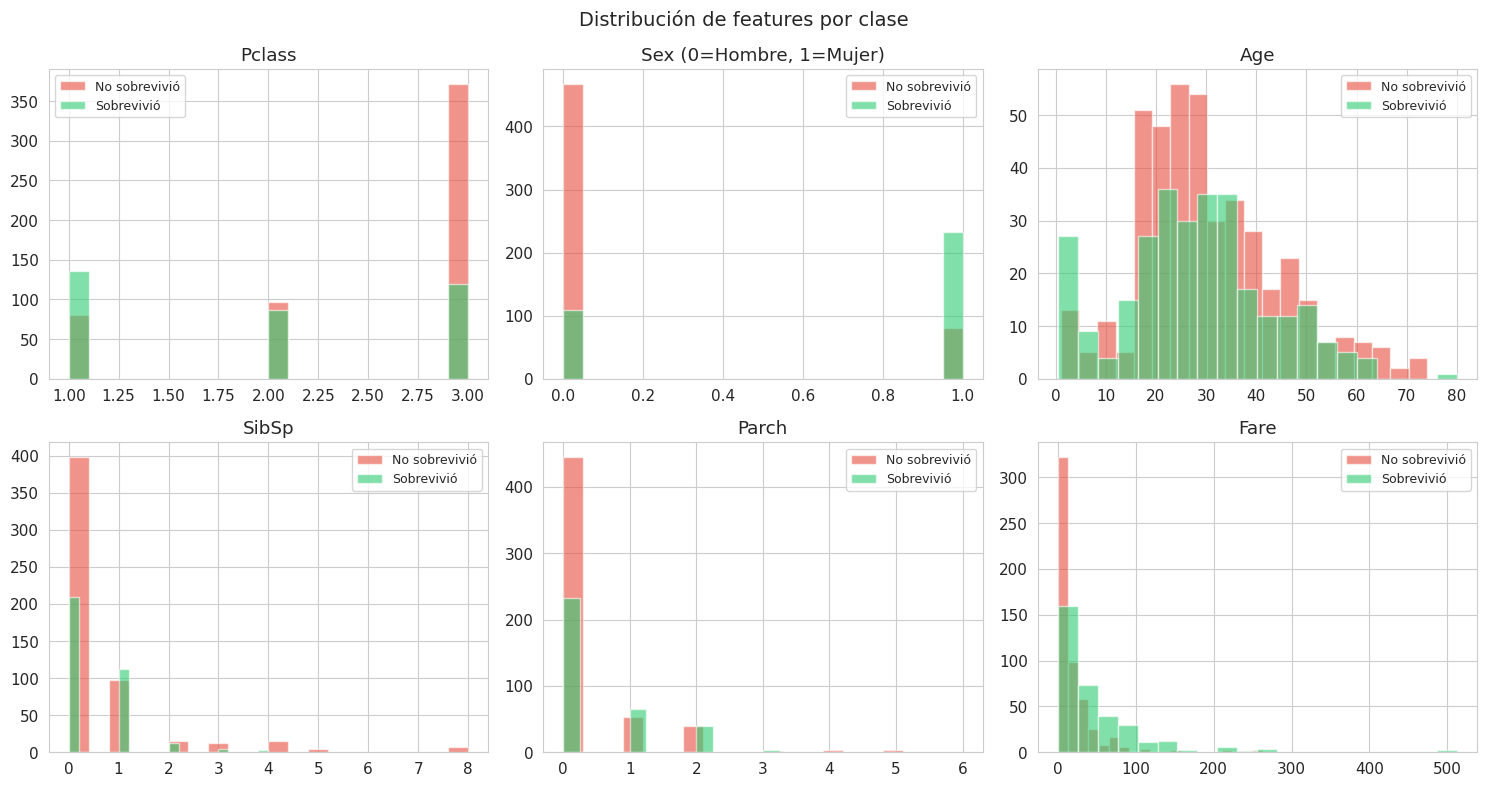

In [ ]:
# 3.2  Distribución de features clave por clase
eda_df = df.copy()
eda_df['Sex_num'] = eda_df['Sex'].map({'male': 0, 'female': 1})

key_features = ['Pclass', 'Sex_num', 'Age', 'SibSp', 'Parch', 'Fare']
feature_titles = ['Pclass', 'Sex (0=Hombre, 1=Mujer)', 'Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (feat, title) in enumerate(zip(key_features, feature_titles)):
    ax = axes[i//3, i%3]
    for label, color, name in zip([0, 1], colors, ['No sobrevivió', 'Sobrevivió']):
        subset = eda_df[eda_df['Survived'] == label][feat].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=name)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

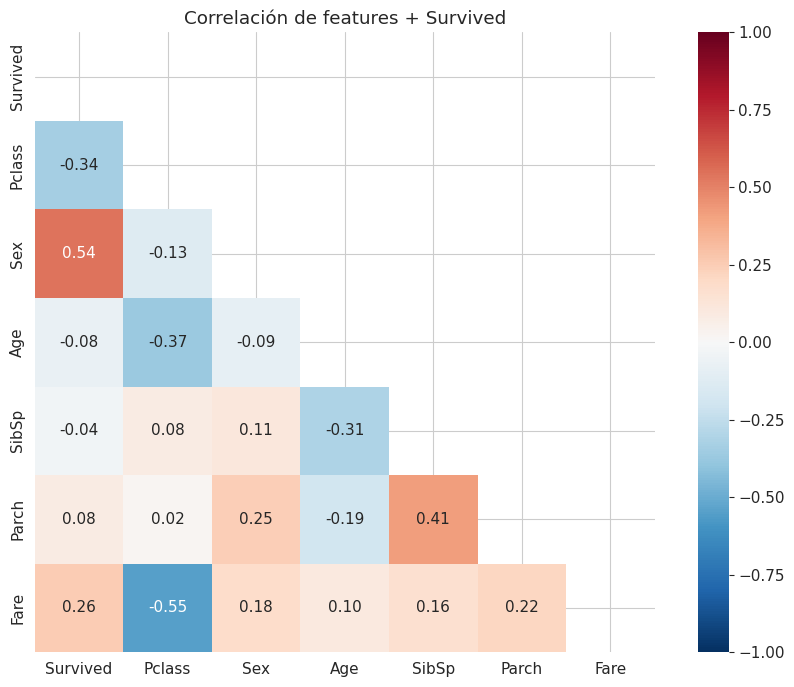

In [ ]:
# 3.3  Matriz de correlación
corr_df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
corr_df['Sex'] = corr_df['Sex'].map({'male': 0, 'female': 1})

plt.figure(figsize=(9, 7))
corr = corr_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True
)
plt.title('Correlación de features + Survived')
plt.tight_layout()
plt.show()

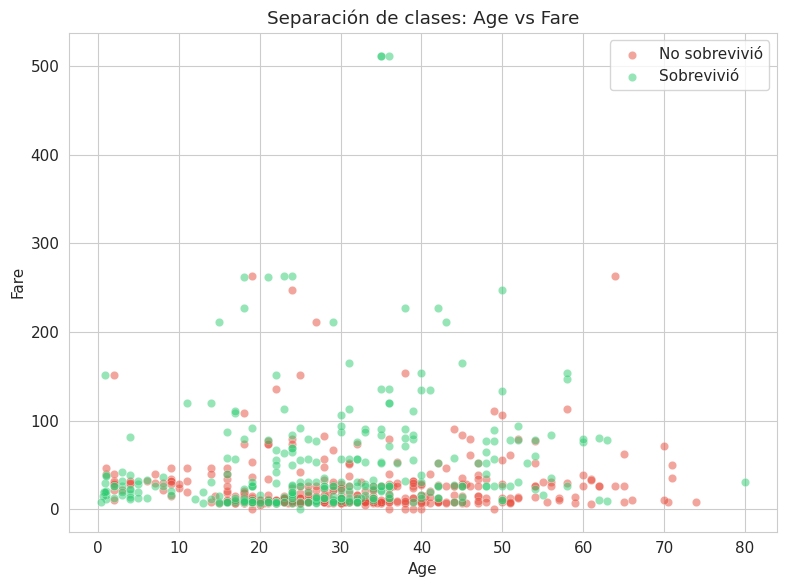

In [ ]:
# 3.4  Scatter plot: Edad vs Tarifa
fig, ax = plt.subplots(figsize=(8, 6))

for label, color, name in zip([0, 1], colors, ['No sobrevivió', 'Sobrevivió']):
    mask = df['Survived'] == label
    ax.scatter(
        df.loc[mask, 'Age'],
        df.loc[mask, 'Fare'],
        alpha=0.5,
        c=color,
        label=name,
        edgecolors='w',
        linewidth=0.3
    )

ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_title('Separación de clases: Age vs Fare')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

Para mantener el modelado sencillo, `Sex` se codifica como **0 = hombre** y **1 = mujer**. Los valores faltantes de `Age` se completan con la mediana calculada únicamente sobre el conjunto de entrenamiento.

In [ ]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

model_df = df[['Survived'] + features].copy()
model_df['Sex'] = model_df['Sex'].map({'male': 0, 'female': 1})

X = model_df[features].copy()
y = model_df['Survived'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputación simple de Age usando solo la mediana del train
age_median = X_train['Age'].median()
X_train['Age'] = X_train['Age'].fillna(age_median)
X_test['Age'] = X_test['Age'].fillna(age_median)

print(f'Mediana de Age usada para imputación: {age_median:.1f}')
print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} sobrevivió')
print(f'Proporción en test:  {y_test.mean():.1%} sobrevivió')
print(f'\nValores faltantes en train: {X_train.isnull().sum().sum()}')
print(f'Valores faltantes en test:  {X_test.isnull().sum().sum()}')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Mediana de Age usada para imputación: 28.5
Entrenamiento: 712 muestras
Test:          179 muestras

Proporción en train: 38.3% sobrevivió
Proporción en test:  38.5% sobrevivió

Valores faltantes en train: 0
Valores faltantes en test:  0


### Funciones auxiliares para evaluación de clasificadores

In [ ]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
        xticklabels=['No sobrevivió', 'Sobrevivió'],
        yticklabels=['No sobrevivió', 'Sobrevivió']
    )
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Desglose TN, FP, FN, TP
    tn, fp, fn, tp = cm.ravel()
    labels = [
        'TN\n(no sobrevivió\ncorrecto)',
        'FP\n(no sobrevivió→\nsobrevivió)',
        'FN\n(sobrevivió→\nno sobrevivió)',
        'TP\n(sobrevivió\ncorrecto)'
    ]
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  FN (sobreviviente no detectado): {fn}')
    print(f'  FP (no sobreviviente como sobreviviente): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(
        y_te, y_pred,
        target_names=['No sobrevivió', 'Sobrevivió']
    ))

    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None

    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr, tpr, linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.4f})'
    )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()

    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal y sus coeficientes permiten observar qué variables influyen de forma positiva o negativa en la predicción.

In [ ]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(
    pipe_lr, X_train, y_train, cv=skf,
    scoring=['accuracy', 'f1', 'recall'],
    return_train_score=True
)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.7879 ± 0.0231
  F1-Score:  0.7159 ± 0.0263
  Recall:    0.6960 ± 0.0337


=== Regresión Logística ===
  Accuracy: 0.8101
  Precision: 0.7778
  Recall: 0.7101
  F1-Score: 0.7424


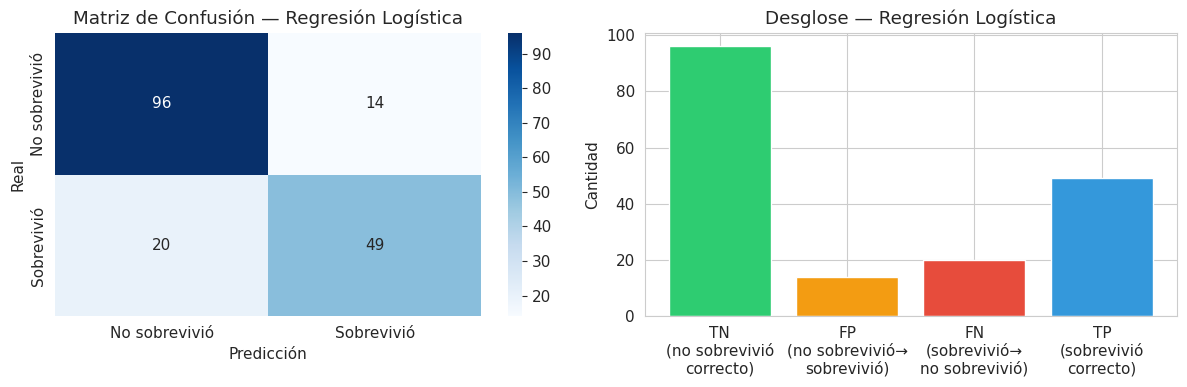


  FN (sobreviviente no detectado): 20
  FP (no sobreviviente como sobreviviente): 14

Reporte completo:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.87      0.85       110
   Sobrevivió       0.78      0.71      0.74        69

     accuracy                           0.81       179
    macro avg       0.80      0.79      0.80       179
 weighted avg       0.81      0.81      0.81       179



In [ ]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(
    pipe_lr, X_train, y_train, X_test, y_test,
    'Regresión Logística'
)

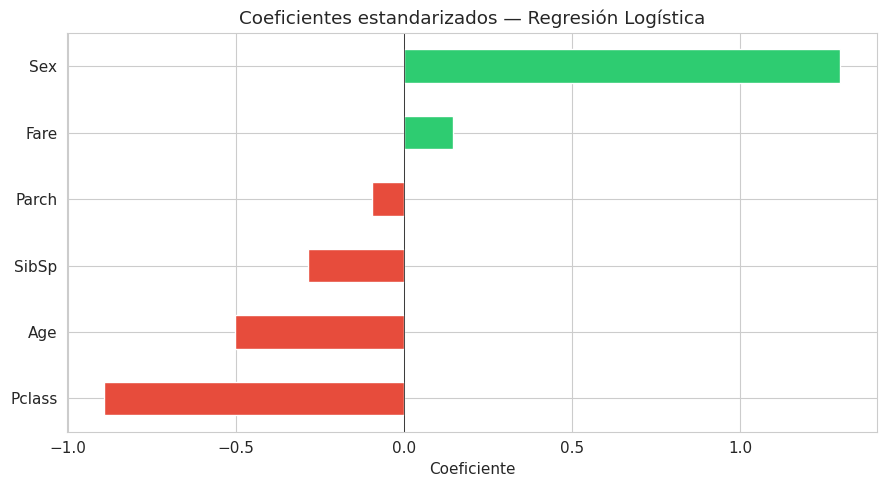

Interpretación:
  → Features que más reducen la probabilidad de sobrevivir: ['Pclass', 'Age']
  → Features que más aumentan la probabilidad de sobrevivir: ['Fare', 'Sex']


In [ ]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más reducen la probabilidad de sobrevivir: {coefs.head(2).index.tolist()}')
print(f'  → Features que más aumentan la probabilidad de sobrevivir: {coefs.tail(2).index.tolist()}')

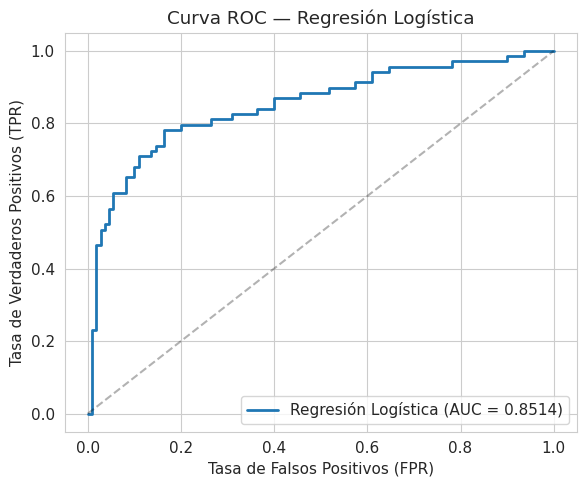

AUC: 0.8514


In [ ]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(
    pipe_lr, X_test, y_test,
    'Regresión Logística', ax
)
plt.tight_layout()
plt.show()

print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la variable y el umbral que reducen mejor la impureza. Su principal ventaja es que las reglas obtenidas son fáciles de interpretar.

In [ ]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(
    pipe_dt_full, X_train, y_train, cv=skf,
    scoring=['accuracy', 'f1', 'recall'],
    return_train_score=True
)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print('\n⚠ Una diferencia alta entre train y validación indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 0.9845
  Test Accuracy:  0.7880 ± 0.0238
  Test F1-Score:  0.7188 ± 0.0385

⚠ Una diferencia alta entre train y validación indica sobreajuste


In [ ]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(
    pipe_dt, X_train, y_train, cv=skf,
    scoring=['accuracy', 'f1', 'recall'],
    return_train_score=True
)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.8501
  Test Accuracy:  0.8146 ± 0.0093
  Test F1-Score:  0.7336 ± 0.0155
  Test Recall:    0.6669 ± 0.0334


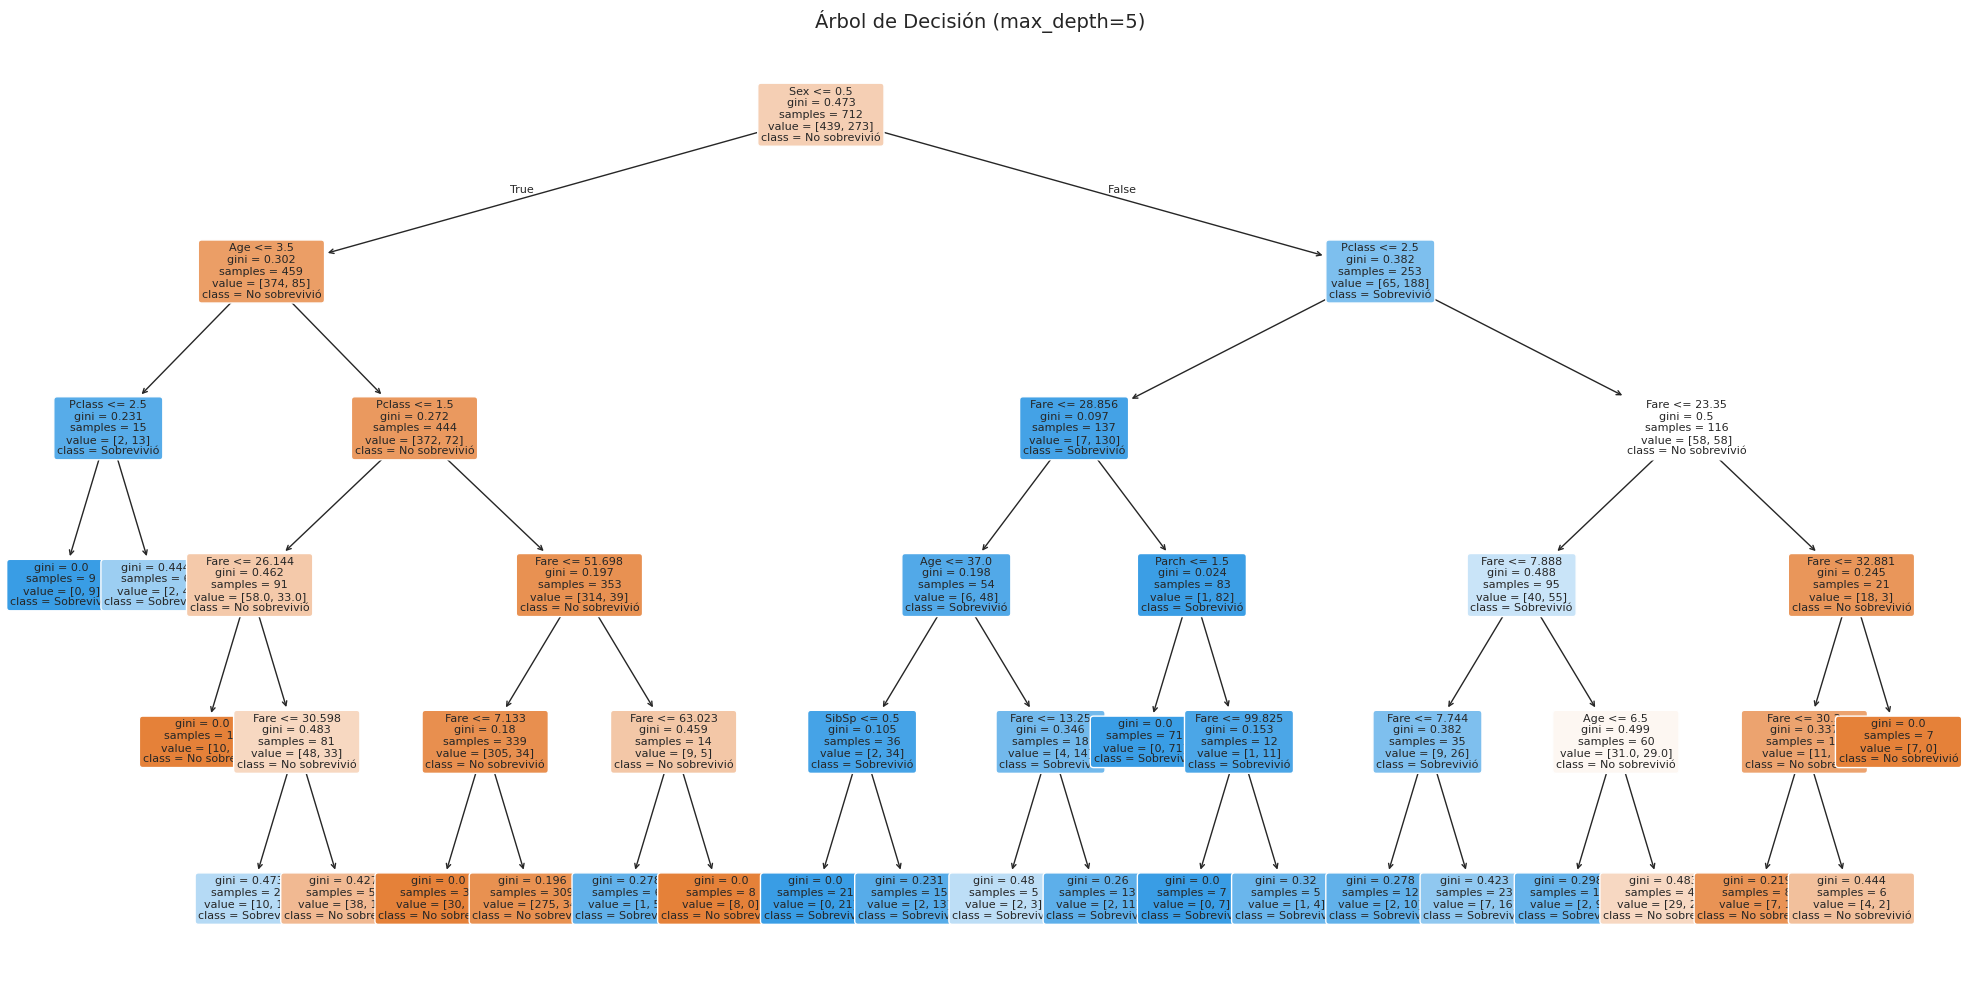

In [ ]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=features,
    class_names=['No sobrevivió', 'Sobrevivió'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.7486
  Precision: 0.7222
  Recall: 0.5652
  F1-Score: 0.6341


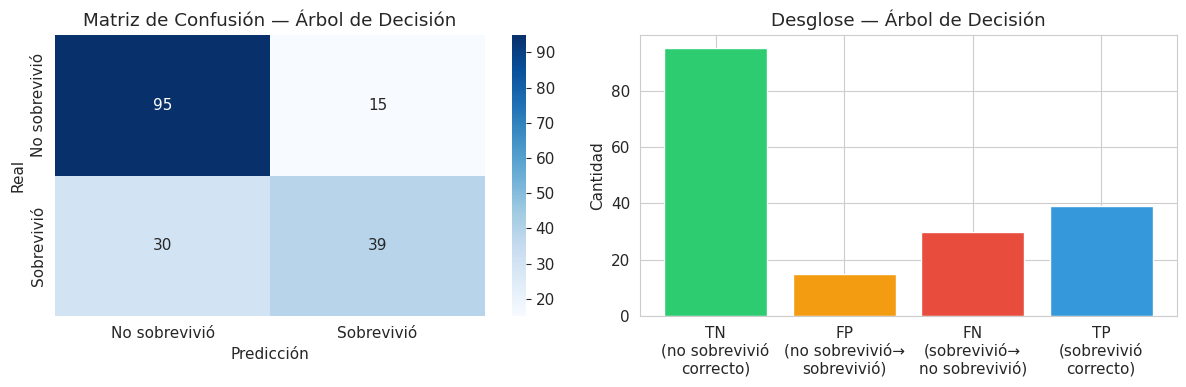


  FN (sobreviviente no detectado): 30
  FP (no sobreviviente como sobreviviente): 15

Reporte completo:
               precision    recall  f1-score   support

No sobrevivió       0.76      0.86      0.81       110
   Sobrevivió       0.72      0.57      0.63        69

     accuracy                           0.75       179
    macro avg       0.74      0.71      0.72       179
 weighted avg       0.75      0.75      0.74       179



In [ ]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(
    pipe_dt, X_train, y_train, X_test, y_test,
    'Árbol de Decisión'
)

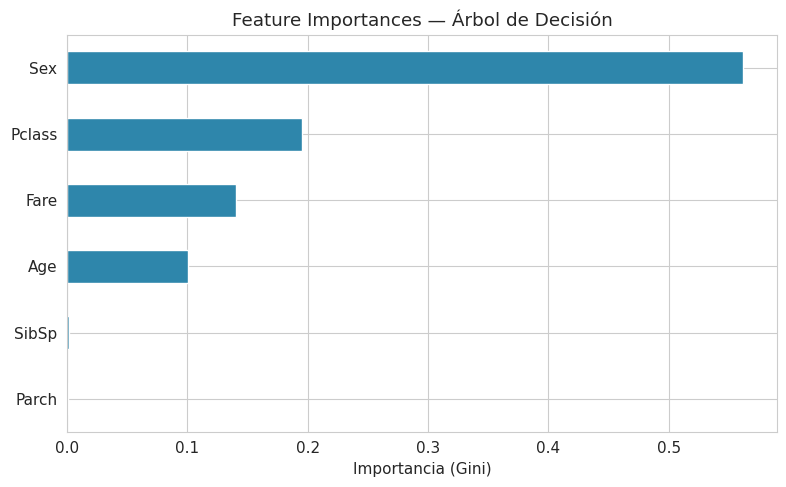

In [ ]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

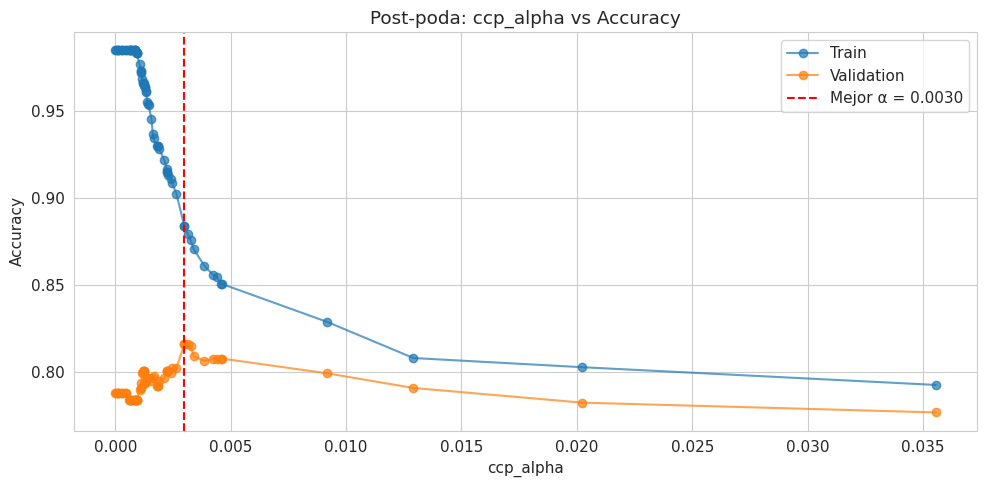

Mejor ccp_alpha: 0.002996


In [ ]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    X_train, y_train
)
alphas = path.ccp_alphas[:-1]

train_scores, test_scores = [], []

for alpha in alphas:
    dt_temp = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )
    cv_temp = cross_validate(
        dt_temp, X_train, y_train,
        cv=skf,
        scoring='accuracy',
        return_train_score=True
    )
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)

best_idx = np.argmax(test_scores)
ax.axvline(
    x=alphas[best_idx],
    color='red',
    linestyle='--',
    label=f'Mejor α = {alphas[best_idx]:.4f}'
)

ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca un hiperplano que separe las clases con el mayor margen posible. Mediante kernels puede construir fronteras de decisión no lineales. En este ejercicio se utiliza principalmente el kernel RBF.

In [ ]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        random_state=42
    ))
])

cv_svm = cross_validate(
    pipe_svm, X_train, y_train, cv=skf,
    scoring=['accuracy', 'f1', 'recall'],
    return_train_score=True
)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.8245 ± 0.0157
  F1-Score:  0.7574 ± 0.0202
  Recall:    0.7143 ± 0.0239


=== SVM (RBF) ===
  Accuracy: 0.8324
  Precision: 0.8305
  Recall: 0.7101
  F1-Score: 0.7656


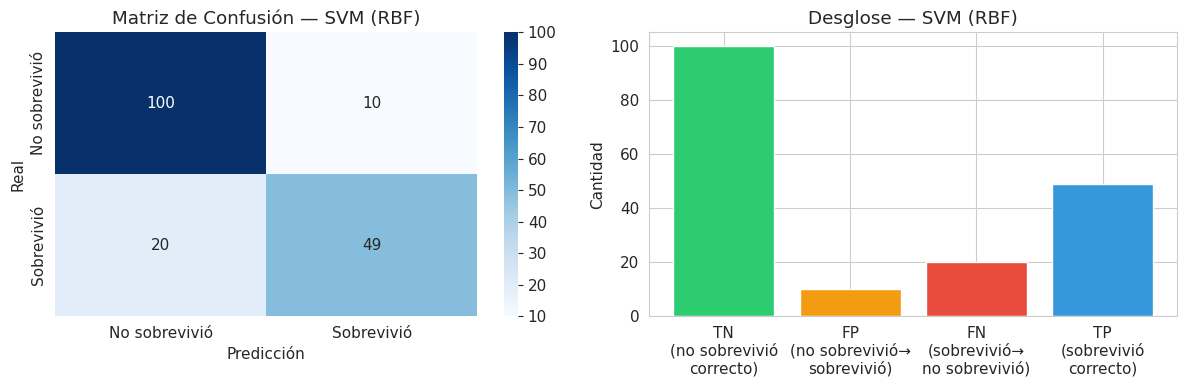


  FN (sobreviviente no detectado): 20
  FP (no sobreviviente como sobreviviente): 10

Reporte completo:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.91      0.87       110
   Sobrevivió       0.83      0.71      0.77        69

     accuracy                           0.83       179
    macro avg       0.83      0.81      0.82       179
 weighted avg       0.83      0.83      0.83       179



In [ ]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(
    pipe_svm, X_train, y_train, X_test, y_test,
    'SVM (RBF)'
)

  Kernel linear  : Accuracy = 0.7894


  Kernel rbf     : Accuracy = 0.8245


  Kernel poly    : Accuracy = 0.8174


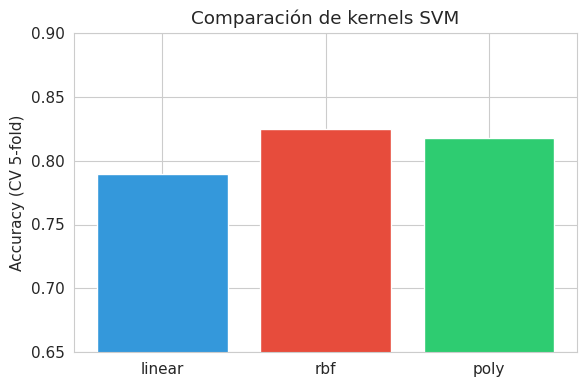

In [ ]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel=k,
            C=1.0,
            probability=True,
            random_state=42
        ))
    ])

    cv_k = cross_validate(
        pipe_k, X_train, y_train,
        cv=skf,
        scoring='accuracy'
    )

    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    kernel_results.keys(),
    kernel_results.values(),
    color=['#3498db', '#e74c3c', '#2ecc71']
)
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.65, 0.90)
plt.tight_layout()
plt.show()

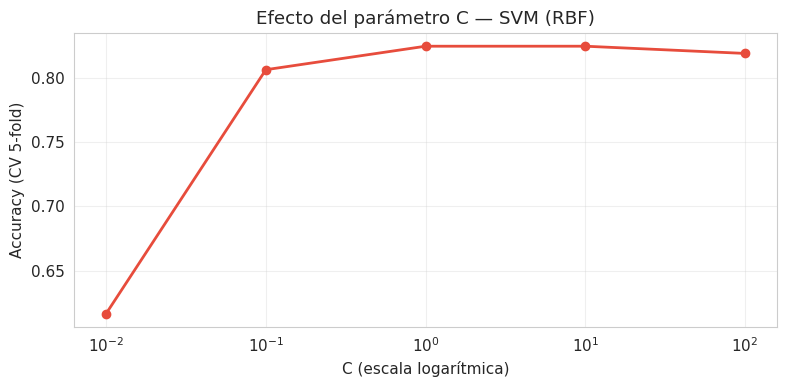


Interpretación:
  C bajo → margen amplio, se permiten más errores
  C alto → margen más estrecho, se penalizan más los errores


In [ ]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])

    cv_c = cross_validate(
        pipe_c, X_train, y_train,
        cv=skf,
        scoring='accuracy'
    )
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(
    C_values, c_scores, 'o-',
    color='#e74c3c',
    linewidth=2
)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, se permiten más errores')
print('  C alto → margen más estrecho, se penalizan más los errores')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** KNN clasifica cada nueva observación según las clases de sus vecinos más cercanos. Como depende de distancias, es importante estandarizar las variables antes del entrenamiento.

In [ ]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(
    pipe_knn, X_train, y_train, cv=skf,
    scoring=['accuracy', 'f1', 'recall'],
    return_train_score=True
)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.8203 ± 0.0240
  F1-Score:  0.7551 ± 0.0295
  Recall:    0.7215 ± 0.0325


=== KNN (K=5) ===
  Accuracy: 0.8156
  Precision: 0.7727
  Recall: 0.7391
  F1-Score: 0.7556


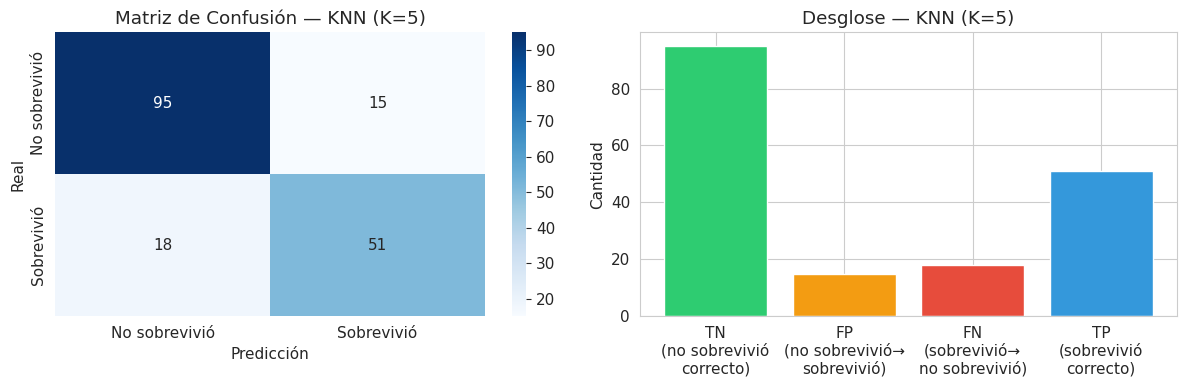


  FN (sobreviviente no detectado): 18
  FP (no sobreviviente como sobreviviente): 15

Reporte completo:
               precision    recall  f1-score   support

No sobrevivió       0.84      0.86      0.85       110
   Sobrevivió       0.77      0.74      0.76        69

     accuracy                           0.82       179
    macro avg       0.81      0.80      0.80       179
 weighted avg       0.81      0.82      0.81       179



In [ ]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(
    pipe_knn, X_train, y_train, X_test, y_test,
    'KNN (K=5)'
)

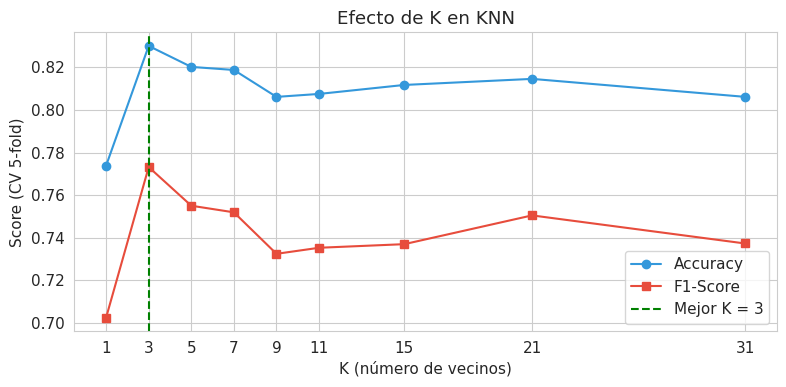

Mejor K por F1: 3
K empírico (√712): 26


In [ ]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])

    cv_k = cross_validate(
        pipe_k, X_train, y_train,
        cv=skf,
        scoring=['accuracy', 'f1']
    )

    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')

best_k = k_values[np.argmax(k_scores_f1)]

ax.axvline(
    x=best_k,
    color='green',
    linestyle='--',
    label=f'Mejor K = {best_k}'
)
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [ ]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2

    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(
            n_neighbors=5,
            metric=d,
            p=p_val
        ))
    ])

    cv_d = cross_validate(
        pipe_d, X_train, y_train,
        cv=skf,
        scoring='f1'
    )

    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.7551
  Distancia manhattan           : F1 = 0.7671
  Distancia minkowski (p=3)     : F1 = 0.7459


---
## 9. Modelo 5 — Random Forest

**Fundamento:** Random Forest combina múltiples árboles de decisión entrenados con diferentes muestras y subconjuntos de variables. La predicción final se obtiene mediante votación, lo que ayuda a reducir el sobreajuste de un árbol individual.

In [ ]:
# 9.1  Entrenamiento y validación cruzada
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

cv_rf = cross_validate(
    pipe_rf, X_train, y_train, cv=skf,
    scoring=['accuracy', 'f1', 'recall'],
    return_train_score=True
)

print('Random Forest (200 árboles) — CV 5-fold')
print(f'  Train Accuracy: {cv_rf["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_rf["test_accuracy"].mean():.4f} ± {cv_rf["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_rf["test_f1"].mean():.4f} ± {cv_rf["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_rf["test_recall"].mean():.4f} ± {cv_rf["test_recall"].std():.4f}')

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

Random Forest (200 árboles) — CV 5-fold
  Train Accuracy: 0.9845
  Test Accuracy:  0.8174 ± 0.0214
  Test F1-Score:  0.7570 ± 0.0220
  Test Recall:    0.7399 ± 0.0189


=== Random Forest ===
  Accuracy: 0.8156
  Precision: 0.7812
  Recall: 0.7246
  F1-Score: 0.7519


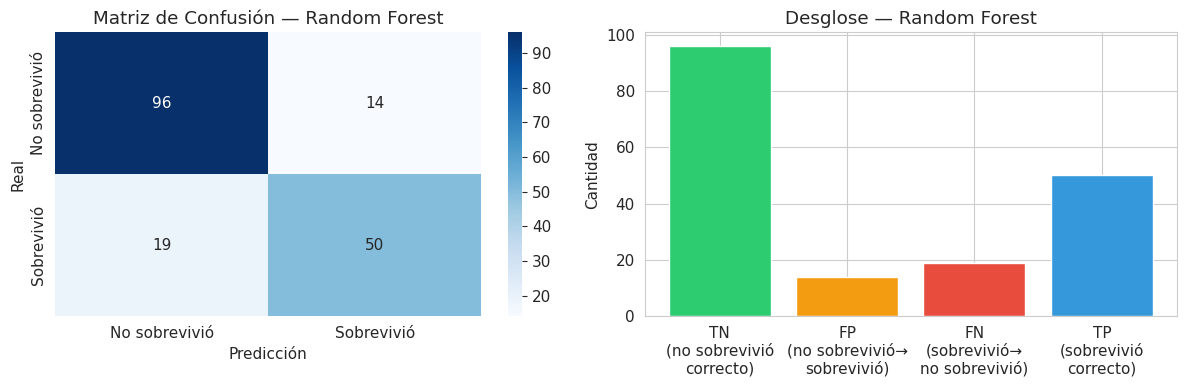


  FN (sobreviviente no detectado): 19
  FP (no sobreviviente como sobreviviente): 14

Reporte completo:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.87      0.85       110
   Sobrevivió       0.78      0.72      0.75        69

     accuracy                           0.82       179
    macro avg       0.81      0.80      0.80       179
 weighted avg       0.81      0.82      0.81       179



In [ ]:
# 9.2  Evaluación completa
metrics_rf = eval_classifier(
    pipe_rf, X_train, y_train, X_test, y_test,
    'Random Forest'
)

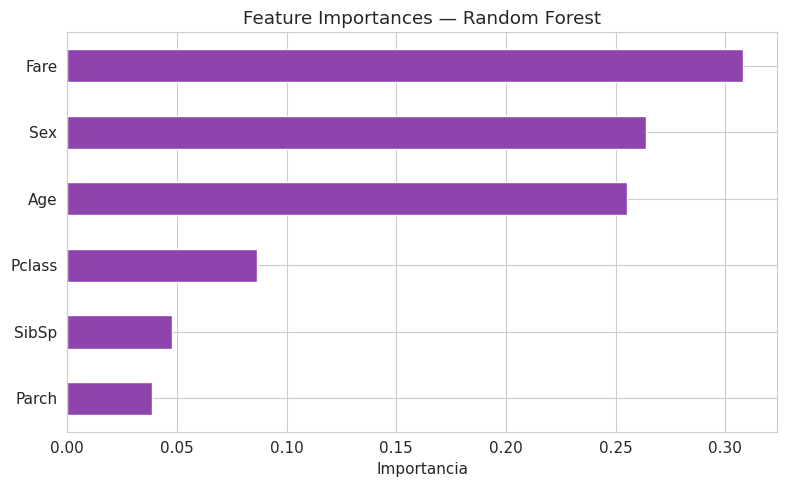

In [ ]:
# 9.3  Importancia de features
rf_importances = pd.Series(
    pipe_rf.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
rf_importances.plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

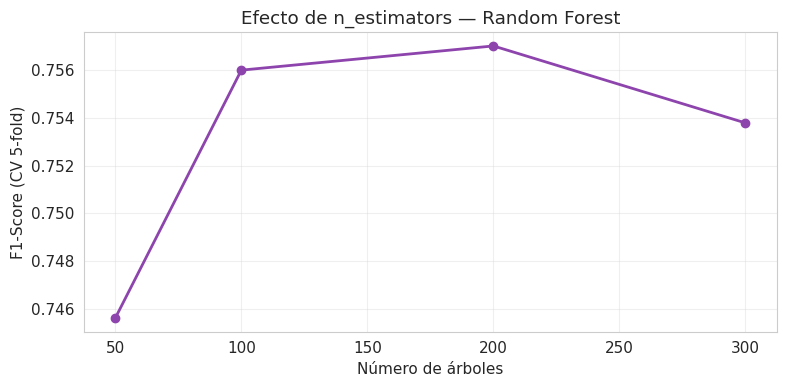

   50 árboles: F1 = 0.7456
  100 árboles: F1 = 0.7560
  200 árboles: F1 = 0.7570
  300 árboles: F1 = 0.7538


In [ ]:
# 9.4  Efecto del número de árboles
n_estimators_values = [50, 100, 200, 300]
rf_scores = []

for n in n_estimators_values:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    cv_temp = cross_validate(
        rf_temp, X_train, y_train,
        cv=skf,
        scoring='f1'
    )
    rf_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    n_estimators_values, rf_scores,
    'o-', color='#8e44ad', linewidth=2
)
ax.set_xlabel('Número de árboles')
ax.set_ylabel('F1-Score (CV 5-fold)')
ax.set_title('Efecto de n_estimators — Random Forest')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for n, score in zip(n_estimators_values, rf_scores):
    print(f'  {n:3d} árboles: F1 = {score:.4f}')

---
## 10. Comparación final de modelos

In [ ]:
# 10.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn,
    'Random Forest': pipe_rf
}

all_metrics = {}

for name, model in all_models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)

print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.8101,0.7778,0.7101,0.7424,0.8514
Árbol de Decisión,0.7486,0.7222,0.5652,0.6341,0.8071
SVM (RBF),0.8324,0.8305,0.7101,0.7656,0.8349
KNN (K=5),0.8156,0.7727,0.7391,0.7556,0.8570
Random Forest,0.8156,0.7812,0.7246,0.7519,0.8358


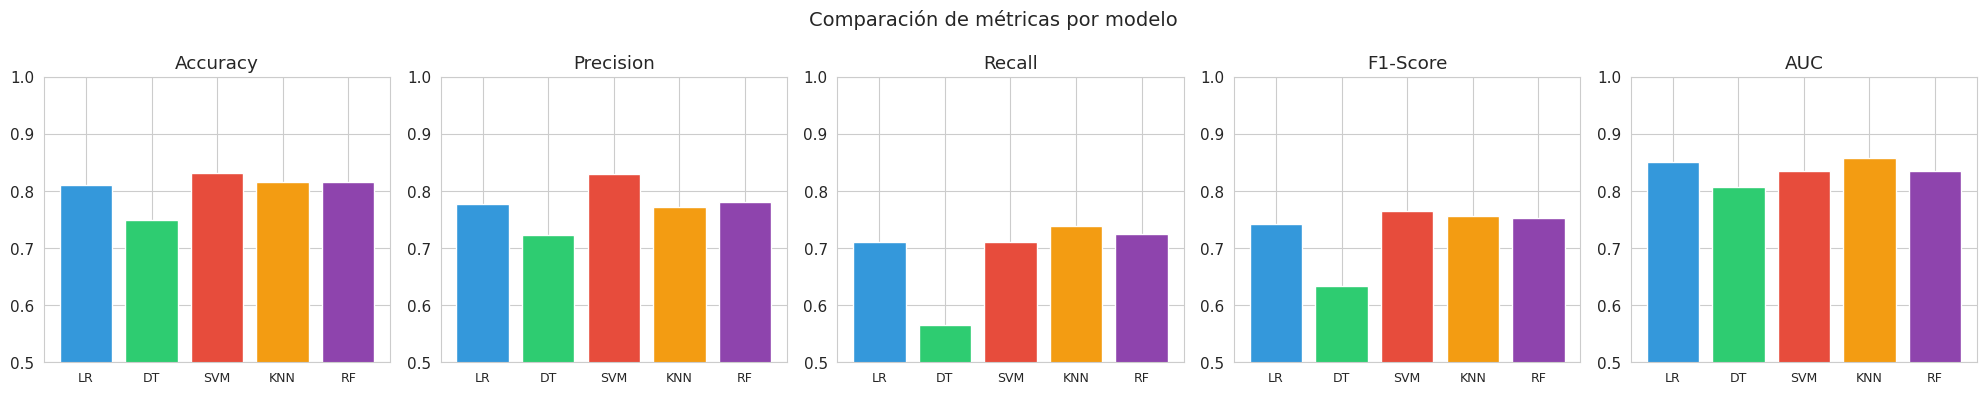

In [ ]:
# 10.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#8e44ad']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]

    axes[i].bar(
        range(len(values)),
        values,
        color=colors_models
    )
    axes[i].set_title(metric)
    axes[i].set_ylim(0.5, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(
        ['LR', 'DT', 'SVM', 'KNN', 'RF'],
        fontsize=9
    )

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

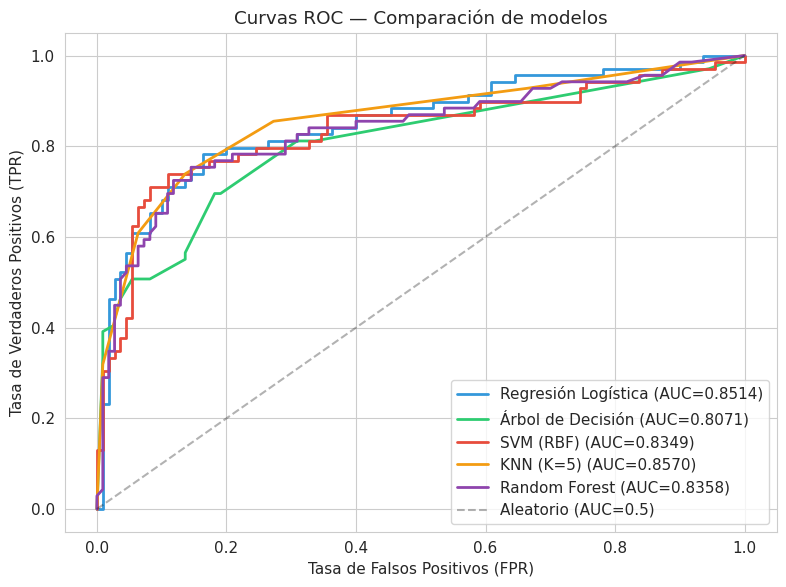

In [ ]:
# 10.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)

    ax.plot(
        fpr, tpr,
        linewidth=2,
        color=color,
        label=f'{name} (AUC={roc_auc_val:.4f})'
    )

ax.plot(
    [0, 1], [0, 1],
    'k--',
    alpha=0.3,
    label='Aleatorio (AUC=0.5)'
)

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# 10.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': [
        'Reg. Logística',
        'Árbol de Decisión',
        'SVM (RBF)',
        'KNN',
        'Random Forest'
    ],
    'Precisión predictiva': [
        '★★★★☆',
        '★★★☆☆',
        '★★★★★',
        '★★★★☆',
        '★★★★☆'
    ],
    'Velocidad (train+pred)': [
        '★★★★★',
        '★★★★☆',
        '★★★☆☆',
        '★★★★☆',
        '★★★☆☆'
    ],
    'Interpretabilidad': [
        '★★★★☆',
        '★★★★★',
        '★★☆☆☆',
        '★★★☆☆',
        '★★★☆☆'
    ],
    'Escalabilidad': [
        '★★★★★',
        '★★★★☆',
        '★★☆☆☆',
        '★★☆☆☆',
        '★★★★☆'
    ],
    'Robustez a outliers': [
        '★★★☆☆',
        '★★★★☆',
        '★★★★☆',
        '★★☆☆☆',
        '★★★★☆'
    ]
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★☆,★★★☆☆,★★☆☆☆,★★☆☆☆
Random Forest,★★★★☆,★★★☆☆,★★★☆☆,★★★★☆,★★★★☆


---
## 11. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Puede quedarse corta con relaciones no lineales | Cuando se busca una clasificación binaria sencilla y explicable |
| **Árbol de Decisión** | Reglas claras, fácil de visualizar, no requiere escalado | Puede sobreajustarse si no se controla su profundidad | Cuando interesa explicar decisiones mediante reglas |
| **SVM** | Buena capacidad para separar clases, funciona bien con variables escaladas | Menor interpretabilidad y mayor costo con datasets grandes | Cuando existen fronteras de decisión complejas |
| **KNN** | Simple, flexible y no paramétrico | Sensible a la escala y más costoso al predecir | En datasets pequeños o medianos con variables normalizadas |
| **Random Forest** | Reduce el sobreajuste de un árbol y maneja relaciones no lineales | Menos interpretable que un solo árbol y requiere más cómputo | Cuando se busca un modelo robusto basado en múltiples árboles |

**Criterio de selección final:** En Titanic existe una diferencia entre la cantidad de pasajeros que sobrevivieron y los que no sobrevivieron, por lo que se toma el **F1-Score** como métrica principal para equilibrar Precision y Recall. En el conjunto de test, **SVM (RBF)** obtiene el mejor F1-Score (**0.7656**) y también la mayor Accuracy (**0.8324**). KNN alcanza el AUC más alto (**0.8570**), pero considerando el criterio principal establecido, **SVM (RBF)** es el modelo seleccionado para este ejercicio.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*